Device utilisé : cpu
Chargement du checkpoint complet : checkpoint_multiasset.pt
✅ Paramètres de marché trouvés dans le checkpoint. Synchronisation Environnement...
Génération de 2000 scénarios de test...


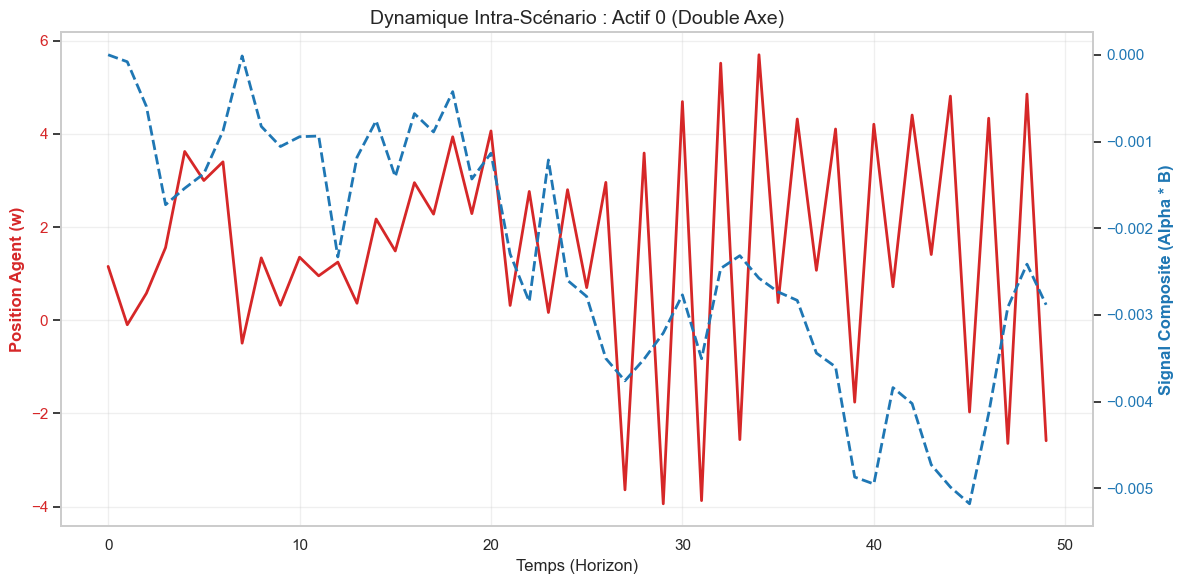

Note : L'axe de droite (Signal) a une échelle beaucoup plus petite que l'axe de gauche.


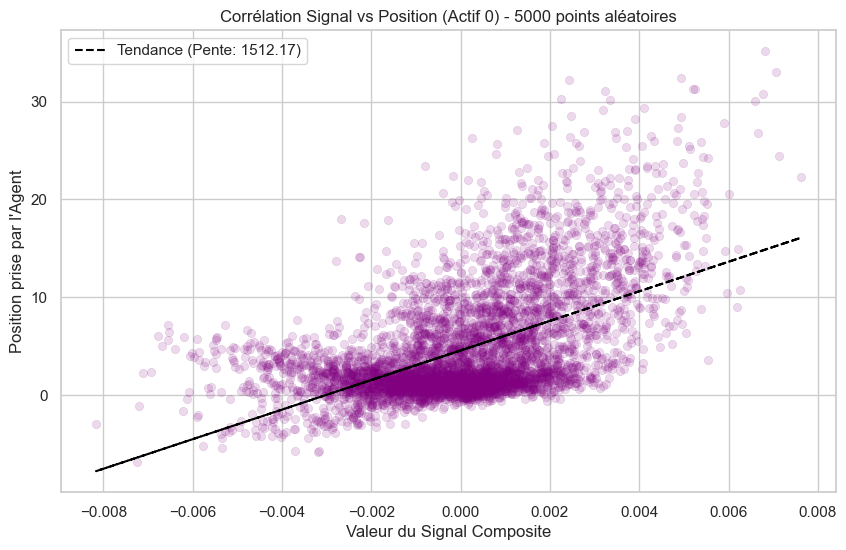

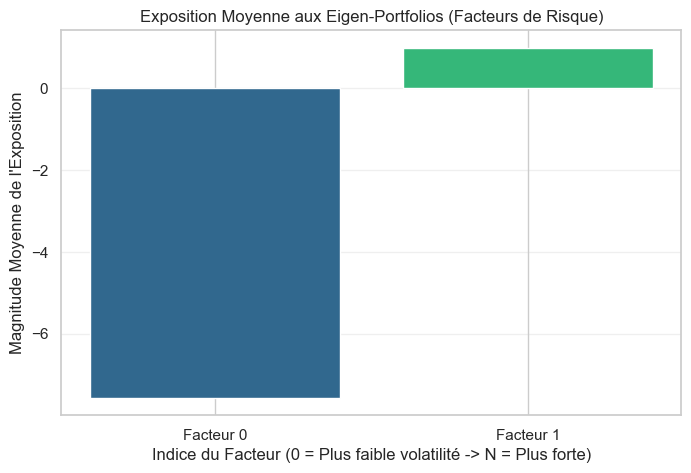

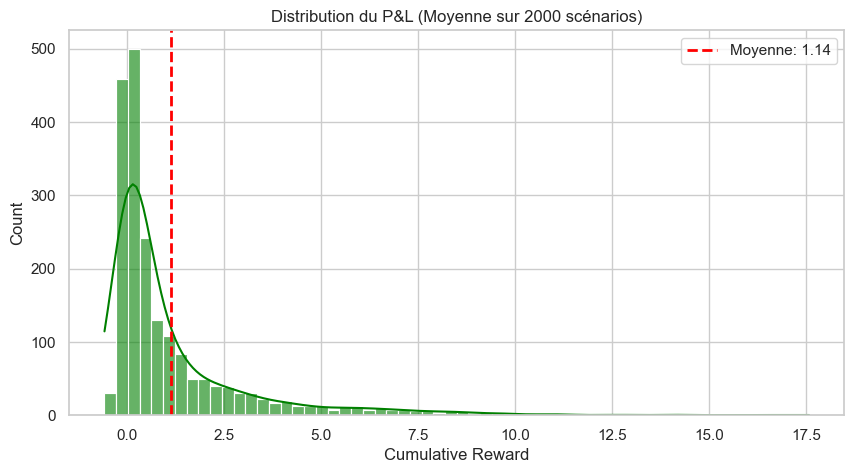

In [4]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# === Importation de vos modules ===
# Assurez-vous que ces fichiers sont dans le même dossier que le notebook
from market_env import MarketEnv
from ddrl_agent import DDRLAgent
from matrices import make_market_params

# === Configuration Graphique ===
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# === 1. Configuration et Chargement ===
device = "cuda" if torch.cuda.is_available() else "cpu"
checkpoint_path = "checkpoint_multiasset.pt"
fallback_model_path = "policy_multiasset_quadratic.pt"

print(f"Device utilisé : {device}")

# Logique de chargement intelligente
try:
    if os.path.exists(checkpoint_path):
        print(f"Chargement du checkpoint complet : {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        
        # Cas 1 : Le fichier contient bien les paramètres de marché (Le cas idéal)
        if 'market_params' in checkpoint:
            print("✅ Paramètres de marché trouvés dans le checkpoint. Synchronisation Environnement...")
            mp = checkpoint['market_params']
            
            # Recréation de l'environnement EXACT de l'entraînement
            env = MarketEnv(
                alpha_weights=mp['alpha_weights'],
                omega=mp['omega'],
                return_weights=mp['return_weights'],
                sigma=mp['sigma'],
                trader_risk=mp['trader_risk'],
                dealer_risk=mp['dealer_risk'],
                horizon=mp['horizon'],
                device=device
            )
            
            agent = DDRLAgent(env=env, horizon=mp['horizon'], hidden_dim=300, device=device)
            agent.policy.load_state_dict(checkpoint['model_state_dict'])
            
        else:
            # Cas 2 : Checkpoint existe mais ancien format (juste les poids)
            print("⚠️ Checkpoint trouvé mais sans paramètres de marché. Utilisation de paramètres ALÉATOIRES (Performance dégradée attendue).")
            raise KeyError("market_params missing")
            
    elif os.path.exists(fallback_model_path):
        print(f"⚠️ Checkpoint complet introuvable. Chargement du modèle simple : {fallback_model_path}")
        print("⚠️ Utilisation de paramètres ALÉATOIRES (Performance dégradée attendue).")
        raise FileNotFoundError("Checkpoint missing")
        
    else:
        print("❌ Aucun modèle trouvé. Initialisation aléatoire totale.")
        raise FileNotFoundError("No model found")

except (KeyError, FileNotFoundError):
    # FALLBACK : Génération de nouveaux paramètres (ce qui causait votre problème de performance)
    # On le garde pour que le code ne plante pas si vous n'avez pas encore ré-entrainé.
    num_assets = 2
    num_alphas = 2
    horizon = 50
    trader_risk = 1e-6
    dealer_risk = 1e-6
    
    return_weights, alpha_weights, sigma, omega = make_market_params(num_assets, num_alphas, device)
    
    env = MarketEnv(
        alpha_weights=alpha_weights,
        omega=omega,
        return_weights=return_weights,
        sigma=sigma,
        trader_risk=trader_risk,
        dealer_risk=dealer_risk,
        horizon=horizon,
        device=device
    )
    
    agent = DDRLAgent(env=env, horizon=horizon, hidden_dim=300, device=device)
    
    # Tentative de chargement des poids seuls si disponibles
    if os.path.exists(fallback_model_path):
        agent.policy.load_state_dict(torch.load(fallback_model_path, map_location=device))

agent.policy.eval()

# === 2. Rollout Personnalisé (Extraction Historique) ===

def custom_rollout(agent, num_samples=1000):
    print(f"Génération de {num_samples} scénarios de test...")
    U_test = agent.env.generate_randomness(num_samples)
    
    # Stockage
    all_positions = []  # Actions (w)
    all_signals = []    # Signal composite (B * alpha)
    rewards = torch.zeros(num_samples, device=device)
    
    with torch.no_grad():
        state = agent.env.reset(num_samples)
        
        for t in range(agent.horizon):
            # Extraction
            alpha_t = state[:, 0:agent.env.num_alphas]
            
            # Action
            action = agent.policy(state) # w_t
            
            # Calcul du Signal Composite (Alpha @ B.T)
            # C'est la partie prédictible du rendement
            composite_signal = alpha_t @ agent.env.return_weights.T
            
            # Stockage
            all_positions.append(action.cpu())
            all_signals.append(composite_signal.cpu())
            
            # Step
            rewards += agent.env.reward(state, action)
            state = agent.env.transition(state, action, U_test[:, t, :])
            
    return {
        "positions": torch.stack(all_positions, dim=1).numpy(), # (Batch, T, Assets)
        "signals": torch.stack(all_signals, dim=1).numpy(),     # (Batch, T, Assets)
        "rewards": rewards.cpu().numpy()
    }

history = custom_rollout(agent, num_samples=2000)

# === 3. Visualisation 1 : Double Axe (Position vs Signal) ===
# CORRECTION : Utilisation de twinx() pour voir le signal même s'il est petit

sample_idx = 0  # Premier scénario
asset_idx = 0   # Premier actif

time_steps = np.arange(agent.horizon)
signal_data = history["signals"][sample_idx, :, asset_idx]
position_data = history["positions"][sample_idx, :, asset_idx]

fig, ax1 = plt.subplots(figsize=(12, 6))

# Axe Gauche : Position (Rouge)
color_pos = 'tab:red'
ax1.set_xlabel('Temps (Horizon)')
ax1.set_ylabel('Position Agent (w)', color=color_pos, fontsize=12, fontweight='bold')
ax1.plot(time_steps, position_data, color=color_pos, linewidth=2, label='Position (w)')
ax1.tick_params(axis='y', labelcolor=color_pos)
ax1.grid(True, alpha=0.3)

# Axe Droit : Signal (Bleu) - Échelle différente !
ax2 = ax1.twinx() 
color_sig = 'tab:blue'
ax2.set_ylabel('Signal Composite (Alpha * B)', color=color_sig, fontsize=12, fontweight='bold')
ax2.plot(time_steps, signal_data, color=color_sig, linestyle='--', linewidth=2, label='Signal Predictif')
ax2.tick_params(axis='y', labelcolor=color_sig)
ax2.grid(False) # On évite de surcharger la grille

plt.title(f"Dynamique Intra-Scénario : Actif {asset_idx} (Double Axe)", fontsize=14)
fig.tight_layout()
plt.show()

print("Note : L'axe de droite (Signal) a une échelle beaucoup plus petite que l'axe de gauche.")

# === 4. Visualisation 2 : Corrélation Globale ===
# On vérifie que l'agent achète bien quand le signal est positif

flat_signals = history["signals"][:, :, asset_idx].flatten()
flat_positions = history["positions"][:, :, asset_idx].flatten()

# Sous-échantillonnage pour la rapidité d'affichage
idx = np.random.choice(len(flat_signals), 5000, replace=False)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=flat_signals[idx], y=flat_positions[idx], alpha=0.15, color="purple", edgecolor=None)

# Régression linéaire pour visualiser la tendance
m, b = np.polyfit(flat_signals[idx], flat_positions[idx], 1)
plt.plot(flat_signals[idx], m*flat_signals[idx] + b, color='black', linestyle='--', linewidth=1.5, label=f"Tendance (Pente: {m:.2f})")

plt.title(f"Corrélation Signal vs Position (Actif {asset_idx}) - 5000 points aléatoires")
plt.xlabel("Valeur du Signal Composite")
plt.ylabel("Position prise par l'Agent")
plt.legend()
plt.show()

# === 5. Visualisation 3 : Eigen-Portfolios (Analyse PCA) ===
# L'agent a-t-il appris la structure de corrélation ?

# 1. Récupération de la matrice de covariance des rendements (Sigma)
cov_mat = agent.env.sigma.cpu().numpy()

# 2. Décomposition en valeurs/vecteurs propres
eigenvals, eigenvecs = np.linalg.eigh(cov_mat) 
# eigenvecs est (N_assets, N_assets), chaque colonne est un vecteur propre

# 3. Projection des positions moyennes de l'agent sur ces vecteurs
# On prend la moyenne des positions absolues pour voir l'exposition au risque "en magnitude"
mean_abs_position = np.abs(history["positions"]).mean(axis=(0,1)) # (Num_Assets,)

# Projection : P_eigen = V.T @ P_asset
# Cela nous dit combien l'agent investit dans le "Facteur 1", "Facteur 2", etc.
eigen_exposures = eigenvecs.T @ mean_abs_position

plt.figure(figsize=(8, 5))
bar_colors = sns.color_palette("viridis", len(eigen_exposures))
plt.bar(range(len(eigen_exposures)), eigen_exposures, color=bar_colors)

plt.title("Exposition Moyenne aux Eigen-Portfolios (Facteurs de Risque)")
plt.xlabel("Indice du Facteur (0 = Plus faible volatilité -> N = Plus forte)")
plt.ylabel("Magnitude Moyenne de l'Exposition")
plt.xticks(range(len(eigen_exposures)), [f"Facteur {i}" for i in range(len(eigen_exposures))])
plt.grid(axis='y', alpha=0.3)
plt.show()

# === 6. Distribution des Profits ===
mean_reward = history["rewards"].mean()
plt.figure(figsize=(10, 5))
sns.histplot(history["rewards"], kde=True, color="green", bins=60, alpha=0.6)
plt.axvline(mean_reward, color='red', linestyle='--', linewidth=2, label=f'Moyenne: {mean_reward:.2f}')
plt.title(f"Distribution du P&L (Moyenne sur {history['rewards'].shape[0]} scénarios)")
plt.xlabel("Cumulative Reward")
plt.legend()
plt.show()


--- Démarrage de la comparaison (N=2000) ---
✅ Vérification Équation A7 (Riccati) : Erreur résiduelle = 1.41e-18
   -> La solution numérique est exacte.
Running DDRL Simulation...
Running GP Oracle Simulation...


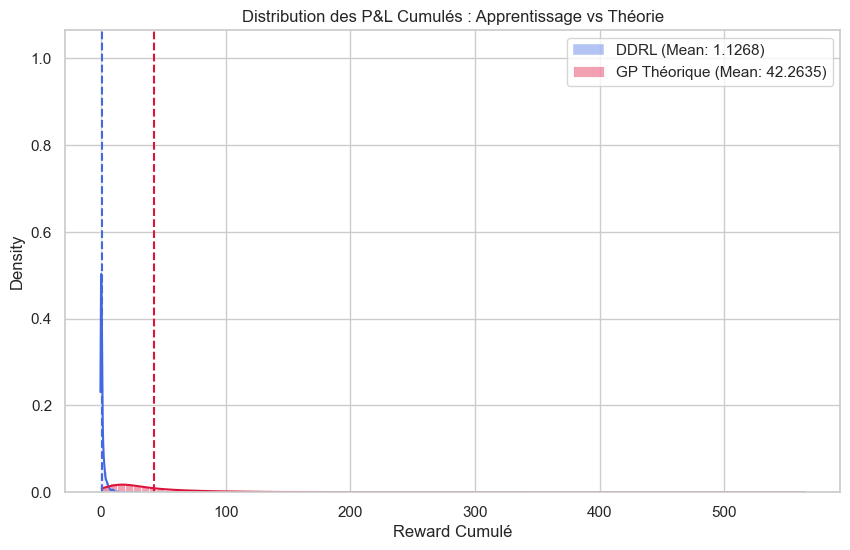

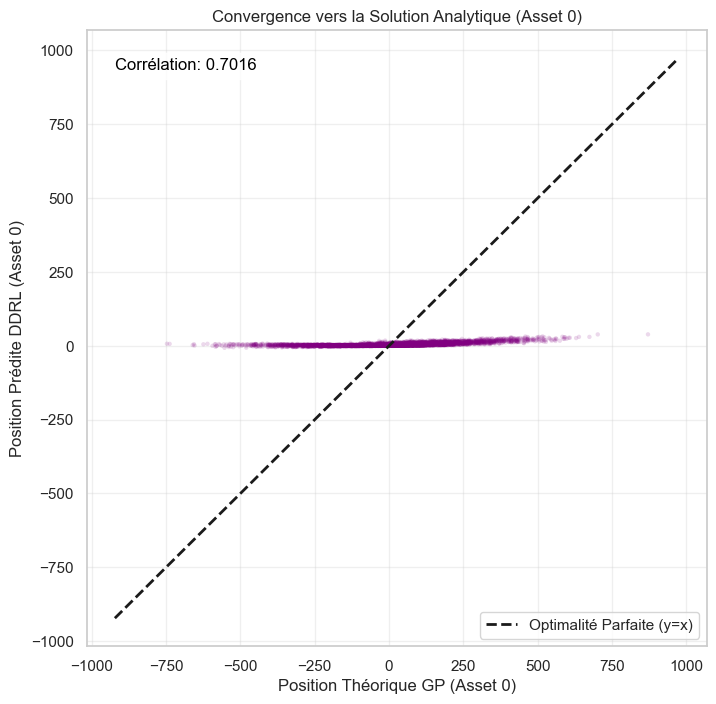

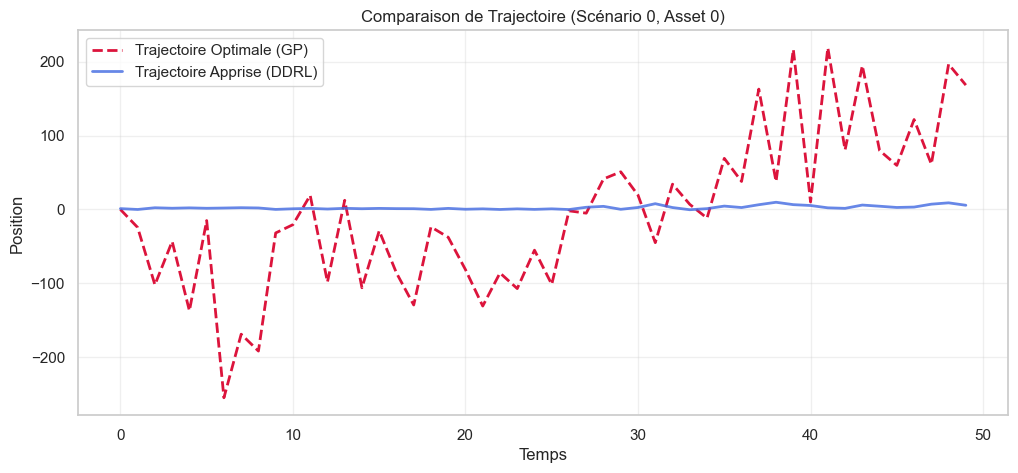

In [5]:
import numpy as np
import scipy.linalg
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# 1. Classe Oracle Gârleanu & Pedersen (Solution Analytique Robuste)
# =============================================================================

class GPAgent:
    """
    Oracle calculant la stratégie optimale théorique de Gârleanu & Pedersen (2013).
    Utilise scipy.linalg.solve_discrete_are pour une précision numérique maximale.
    """
    def __init__(self, env: MarketEnv, discount_factor=0.99): 
        self.env = env
        if isinstance(env.trader_risk, torch.Tensor):
            self.gamma = env.trader_risk.item()
        else:
            self.gamma = float(env.trader_risk)
    # Aversion au risque (scal)
        self.rho = 1 - discount_factor            # Taux d'escompte
        
        # Extraction des matrices sur CPU
        self.B = env.return_weights.detach().cpu().numpy()
        self.Sigma = env.sigma.detach().cpu().numpy()
        self.Lambda = env.cost_lambda.detach().cpu().numpy()
        
        # Phi : Mean Reversion. Dans le code: alpha_next = alpha @ alpha_weights.T
        # Dans le papier: f_{t+1} = (I - Phi) f_t. Donc (I - Phi) = alpha_weights.
        alpha_w = env.alpha_weights.detach().cpu().numpy()
        self.Phi = np.eye(env.num_alphas) - alpha_w
        
        self.num_assets = env.num_assets
        self.num_alphas = env.num_alphas
        
        # Résolution des équations matricielles
        self.A_xx, self.A_xf = self._solve_model_matrices()
        
    def _solve_model_matrices(self):
        """
        Résout l'équation de Riccati (A_xx) et l'équation de Sylvester (A_xf).
        """
        g, S, L = self.gamma, self.Sigma, self.Lambda
        B_mat, Phi = self.B, self.Phi
        beta = 1.0 - self.rho
        
        # --- 1. Résolution de A_xx (Riccati) ---
        # On utilise le solver LQR discret de Scipy.
        # Le problème LQR minimise sum (x'Qx + u'Ru).
        # Ici Q = gamma * Sigma, R = Lambda.
        # Le système est x_{t+1} = x_t + u_t (donc A_sys=I, B_sys=I).
        # Pour inclure le discount factor beta, on scale les matrices système par sqrt(beta).
        
        beta_sqrt = np.sqrt(beta)
        A_sys = beta_sqrt * np.eye(self.num_assets)
        B_sys = beta_sqrt * np.eye(self.num_assets)
        
        # A_xx est la matrice P du LQR (Value Function hessian)
        A_xx = scipy.linalg.solve_discrete_are(A_sys, B_sys, g * S, L)
        
        # --- 2. Résolution de A_xf (Sylvester / Linear System) ---
        # Equation dérivée de (A8) : A_xf - M * A_xf * K = C
        # M = beta * Lambda * (gamma Sigma + Lambda + A_xx)^-1
        # K = (I - Phi)
        
        inv_term = np.linalg.inv(g * S + L + A_xx)
        M = beta * L @ inv_term
        K = np.eye(self.num_alphas) - Phi
        C_mat = M @ B_mat
        
        # Résolution vectorisée : (I - K^T kron M) vec(A_xf) = vec(C)
        kron_prod = np.kron(K.T, M)
        I_big = np.eye(self.num_assets * self.num_alphas)
        vec_C = C_mat.flatten(order='F') # Column-major pour Kronecker
        
        vec_A_xf = np.linalg.solve(I_big - kron_prod, vec_C)
        A_xf = vec_A_xf.reshape((self.num_assets, self.num_alphas), order='F')
        
        return A_xx, A_xf

    def verify_riccati_equation(self):
        """
        Vérifie numériquement que la solution A_xx respecte l'équation A7 du papier.
        Retourne l'erreur maximale absolue.
        """
        # Eq A7 réarrangée (Woodbury sur l'équation de Riccati):
        # A_xx = beta * A_xx - beta^2 * A_xx @ inv(Lambda + beta*A_xx) @ A_xx + gamma*Sigma
        # C'est l'équation de point fixe pour la matrice de coût.
        
        beta = 1.0 - self.rho
        L = self.Lambda
        S = self.Sigma
        g = self.gamma
        P = self.A_xx # P alias A_xx
        
        # Terme de droite de l'équation théorique
        inv_term = np.linalg.inv(L + beta * P)
        rhs = beta * P - (beta * P) @ inv_term @ (beta * P) + g * S
        
        error = np.max(np.abs(P - rhs))
        return error

    def get_optimal_action(self, state_tensor):
        """
        Calcule x_t optimal donné l'état courant.
        """
        state_np = state_tensor.detach().cpu().numpy()
        alpha_t = state_np[:, :self.num_alphas]      # f_t
        prev_pos = state_np[:, self.num_alphas:]     # x_{t-1}
        
        # 1. Aim Portfolio : aim_t = A_xx^-1 * A_xf * f_t
        rhs = (self.A_xf @ alpha_t.T) 
        aim_t = np.linalg.solve(self.A_xx, rhs).T 
        
        # 2. Trading Rule (Prop 2) : x_t = x_{t-1} + Lambda^-1 * A_xx * (aim_t - x_{t-1})
        trade_direction = aim_t - prev_pos
        step = np.linalg.solve(self.Lambda, (self.A_xx @ trade_direction.T)).T
        
        current_pos = prev_pos + step
        return torch.tensor(current_pos, device=self.env.device, dtype=torch.float32)

# =============================================================================
# 2. Routine de Comparaison Complète
# =============================================================================

def compare_strategies_full(agent_ddrl, env, num_samples=2000):
    print(f"--- Démarrage de la comparaison (N={num_samples}) ---")
    
    # 1. Instanciation de l'Oracle GP
    gp_agent = GPAgent(env)
    
    # 2. Vérification Mathématique (Eq A7)
    riccati_error = gp_agent.verify_riccati_equation()
    print(f"✅ Vérification Équation A7 (Riccati) : Erreur résiduelle = {riccati_error:.2e}")
    if riccati_error > 1e-10:
        print("⚠️ ATTENTION : La solution numérique semble imprécise !")
    else:
        print("   -> La solution numérique est exacte.")

    # 3. Génération des scénarios communs
    U_test = env.generate_randomness(num_samples)
    
    # 4. Simulation DDRL (Votre Agent)
    print("Running DDRL Simulation...")
    rewards_ddrl = torch.zeros(num_samples, device=env.device)
    pos_ddrl = []
    
    with torch.no_grad():
        state = env.reset(num_samples)
        for t in range(env.horizon):
            action = agent_ddrl.policy(state)
            pos_ddrl.append(action)
            rewards_ddrl += env.reward(state, action)
            state = env.transition(state, action, U_test[:, t, :])
    pos_ddrl = torch.stack(pos_ddrl, dim=1).cpu().numpy()
    
    # 5. Simulation GP (L'Oracle)
    print("Running GP Oracle Simulation...")
    rewards_gp = torch.zeros(num_samples, device=env.device)
    pos_gp = []
    
    with torch.no_grad():
        state = env.reset(num_samples) 
        for t in range(env.horizon):
            action = gp_agent.get_optimal_action(state)
            pos_gp.append(action)
            rewards_gp += env.reward(state, action)
            state = env.transition(state, action, U_test[:, t, :])
    pos_gp = torch.stack(pos_gp, dim=1).cpu().numpy()
    
    # =========================================================================
    # 6. Visualisations
    # =========================================================================
    
    # A. Distribution des Rewards (P&L)
    plt.figure(figsize=(10, 6))
    sns.histplot(rewards_ddrl.cpu().numpy(), color="royalblue", label=f"DDRL (Mean: {rewards_ddrl.mean():.4f})", kde=True, stat="density", alpha=0.4)
    sns.histplot(rewards_gp.cpu().numpy(), color="crimson", label=f"GP Théorique (Mean: {rewards_gp.mean():.4f})", kde=True, stat="density", alpha=0.4)
    plt.axvline(rewards_ddrl.mean(), color="royalblue", linestyle="--")
    plt.axvline(rewards_gp.mean(), color="crimson", linestyle="--")
    plt.title("Distribution des P&L Cumulés : Apprentissage vs Théorie")
    plt.xlabel("Reward Cumulé")
    plt.legend()
    plt.show()
    
    # B. Scatter Plot de Convergence (Le Test Ultime)
    asset_idx = 0
    # Aplatir toutes les données (Batch x Time)
    flat_gp = pos_gp[:, :, asset_idx].flatten()
    flat_ddrl = pos_ddrl[:, :, asset_idx].flatten()
    
    # Sous-échantillonner pour la lisibilité
    idx = np.random.choice(len(flat_gp), 5000, replace=False)
    
    plt.figure(figsize=(8, 8))
    plt.scatter(flat_gp[idx], flat_ddrl[idx], alpha=0.15, s=10, color="purple", edgecolors='none')
    
    # Ligne d'identité y=x
    mi, ma = flat_gp.min(), flat_gp.max()
    plt.plot([mi, ma], [mi, ma], 'k--', linewidth=2, label="Optimalité Parfaite (y=x)")
    
    # Calcul R2 ou Corrélation
    corr = np.corrcoef(flat_gp, flat_ddrl)[0, 1]
    plt.text(mi, ma, f"Corrélation: {corr:.4f}", fontsize=12, verticalalignment="top", color="black", bbox=dict(facecolor='white', alpha=0.8))

    plt.xlabel(f"Position Théorique GP (Asset {asset_idx})")
    plt.ylabel(f"Position Prédite DDRL (Asset {asset_idx})")
    plt.title(f"Convergence vers la Solution Analytique (Asset {asset_idx})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # C. Trajectoire Temporelle (Zoom sur un scénario)
    scenario_idx = 0
    time_steps = np.arange(env.horizon)
    
    plt.figure(figsize=(12, 5))
    plt.plot(time_steps, pos_gp[scenario_idx, :, asset_idx], label="Trajectoire Optimale (GP)", color="crimson", linewidth=2, linestyle="--")
    plt.plot(time_steps, pos_ddrl[scenario_idx, :, asset_idx], label="Trajectoire Apprise (DDRL)", color="royalblue", linewidth=2, alpha=0.8)
    plt.title(f"Comparaison de Trajectoire (Scénario {scenario_idx}, Asset {asset_idx})")
    plt.xlabel("Temps")
    plt.ylabel("Position")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- Exécution ---
# Assurez-vous d'avoir chargé 'agent' et 'env' au préalable
compare_strategies_full(agent, env, num_samples=2000)
